In [1]:
cd("d:/Master Research/Research-Project")

In [3]:
include(joinpath(@__DIR__,"..", "Helper_util", "util.jl"))
include(joinpath(@__DIR__,"..", "Parameter", "parameter.jl"));

In [10]:
## Define the diffusion coefficients and wave WaveNumber
diffusion_coefficient = DiffusionParameter(1, 0.0001, 0.1, 0.01)

    
total_population=Total_Population(1.75).total


## parameter setting up 2
Nₜ = global_parameter_2.Nₜ
λ, ν = global_parameter_2.λ, global_parameter_2.ν
α, δ, g, m = global_parameter_2.α, global_parameter_2.δ, global_parameter_2.g, global_parameter_2.m
d₁, d₂, d₃, d₄, k = diffusion_coefficient.d₁, diffusion_coefficient.d₂, diffusion_coefficient.d₃, diffusion_coefficient.d₄, WaveNumber(2).k;
d₁_vec=Diffusion_Vec_Parameter(0.1:0.1:10).d_vec;

In [8]:
## Define the diffusion coefficients and wave WaveNumber
diffusion_coefficient = DiffusionParameter(5, 0.001, 0.001, 0.001)


total_population=Total_Population(0.4).total


## parameter setting up 2
Nₜ = global_parameter_1.Nₜ
λ, ν = global_parameter_1.λ, global_parameter_1.ν
α, δ, g, m = global_parameter_2.α, global_parameter_2.δ, global_parameter_2.g, global_parameter_2.m
d₁, d₂, d₃, d₄, k = diffusion_coefficient.d₁, diffusion_coefficient.d₂, diffusion_coefficient.d₃, diffusion_coefficient.d₄, WaveNumber(2).k;
d₁_vec=Diffusion_Vec_Parameter(0.1:0.1:10).d_vec;

In [5]:

function equilibrium_state_4D(N_t, λ, ν, δ, α, g, m)
    ## record the length of vector N_t
    num_pt=length(N_t)
    # Pre-define the vector P_star and N_star as vector to store the equilibrium values for each N_t[i]
    P̄, N̄, Z̄, D̄=zeros(Float64,num_pt), zeros(Float64,num_pt), zeros(Float64,num_pt), zeros(Float64,num_pt)

    # running the for loop for every N_t
    for i in 1:num_pt
        
       b=1+ (ν+δ)/(g-δ) - (λ/δ)*(δ/(g-δ))^m - N_t[i] + (ν/α)*(δ)/(g-δ)
       c=  δ/(g-δ) - (λ/δ)*(δ/(g-δ))^m -N_t[i]

       poly_i = Polynomial([c, b, 1])
       ## Only consider the real roots of above polynomial for solving N
       all_roots = roots(poly_i)
       real_roots = filter(x -> isreal(x), all_roots)
       real_roots = Float64.(real(real_roots))

       ## if there is no such real roots in the restricted range [0,N_t[i]], we use -1 to denote N and P
       if isempty(filter(x -> 0 <= x <= N_t[i], real_roots))
           N̄[i] = -1
           P̄[i] = -1
           D̄[i] = -1
           Z̄[i] = -1
       else
           N̄[i] = filter(x -> 0 <= x <= N_t[i], real_roots)[1]
           P̄[i] = δ/(g-δ)
           D̄[i] = (ν/α)*(δ)/(g-δ) * N̄[i]/(1+N̄[i])
           Z̄[i] = N_t[i] - N̄[i] - P̄[i] - D̄[i]
       end
       
       ## make a double check that all N P Z are in the range of [0, N_t]
       if !(0 <= N̄[i] <= N_t[i] && 0 <= P̄[i] <= N_t[i] && 0 <= Z̄[i] <= N_t[i] && 0 <= D̄[i] <= N_t[i])
        N̄[i], P̄[i], Z̄[i] = -1, -1, -1
       end
   end
   
   return(N̄,P̄,Z̄,D̄)
end

equilibrium_state_4D (generic function with 1 method)

In [10]:

# Function to plot the equilibrium states
function plot_equilibrium_4D(N_t, λ, ν, δ, α, g, m)

    N̄, P̄, Z̄, D̄= equilibrium_state_4D(N_t, λ, ν, δ, α, g, m)
    computational_sum=N̄+P̄+Z̄+D̄

    plot(N_t, N̄, label="N", lw=2)
    plot!(N_t, P̄, label="P", lw=2)
    plot!(N_t, Z̄, label="Z", lw=2)
    plot!(N_t, D̄, label="D", lw=2)
    plot!(N_t,computational_sum,label="actual sum", linestyle=:dash)
    xlabel!("total population")
    ylabel!("Equilibrium Values")
    title!("Equilibrium Plot")
end

plot_equilibrium_4D (generic function with 1 method)

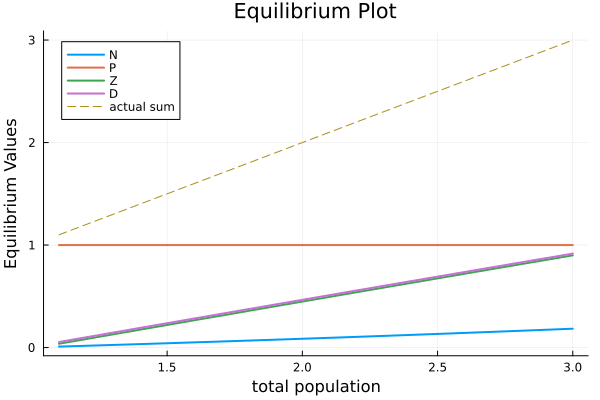

In [13]:
plot_equilibrium_4D(1.1:0.1:3, λ, ν, δ, α, g, m)

In [14]:
function plot_equilibrium_N_roots(N_t, λ, ν, δ, α, g, m)
    num_pt = length(N_t)
    N̄1, N̄2 = zeros(Float64,num_pt), zeros(Float64,num_pt)

    for i in 1:num_pt
        Nt = N_t[i]

        b = 1 + (ν+δ)/(g-δ) - (λ/δ)*(δ/(g-δ))^m - Nt + (ν/α)*(δ)/(g-δ)
        c = δ/(g-δ) - (λ/δ)*(δ/(g-δ))^m - Nt

        poly_i = Polynomial([c, b, 1])
        all_roots = roots(poly_i)

        N̄1[i] = all_roots[1]
        N̄2[i] = all_roots[2]
        
    end

    # Plot the results
    plot(N_t, N̄1, label="Root 1", lw=2)
    plot!(N_t, N̄2, label="Root 2", lw=2, linestyle=:dash)
    xlabel!("Total N_t")
    ylabel!("Equilibrium N̄")
    title!("Two Equilibrium Solutions for N̄ vs N_t")
    ##return N̄1, N̄2
end

plot_equilibrium_N_roots (generic function with 1 method)

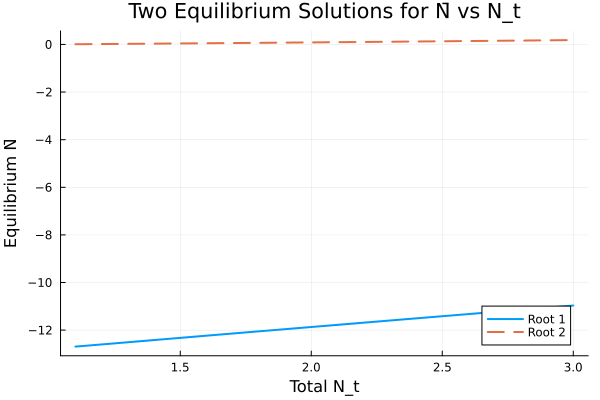

In [15]:
plot_equilibrium_N_roots(1.1:0.1:3, λ, ν, δ, α, g, m)

In [6]:
function ODE_PDE_system_4D(Nₜ, λ, ν, δ, α, g, m, d₁, d₂, d₃, d₄, k)
    N̄,P̄,Z̄,D̄=equilibrium_state_4D(Nₜ, λ, ν, δ, α, g, m)
    result=[]
    for i in 1:length(Nₜ)
        Nᵢ,Pᵢ,Zᵢ, Dᵢ=N̄[i],P̄[i],Z̄[i],D̄[i]
        if Nᵢ == -1 && Pᵢ==-1 && Zᵢ==-1 && Dᵢ==-1
           key=[-0.1, -0.1, -0.1, Nₜ[i]]
        else
           ## Define the Jacobian matrix at equilibrium states
           A=zeros(4,4)
           A=[-ν*Pᵢ/((1+Nᵢ)^2)   -ν*(Nᵢ/(Nᵢ+1))    0      α
              ν*Pᵢ/((1+Nᵢ)^2)    ν*(Nᵢ/(Nᵢ+1))-g*Zᵢ/((1+Pᵢ)^2)-m*λ*Pᵢ^(m-1)  -g*Pᵢ/(1+Pᵢ)    0
              0                  g*Zᵢ/((1+Pᵢ)^2)    0     0
              0                  m*λ*Pᵢ^(m-1)       δ     -α]
           ## define the linear approximation matrix for PDE system
           diffusion_vec=[d₁,d₂,d₃,d₄]
           diffusion_mat=diagm(0 => -(k^2)*diffusion_vec)
           pde_mat=A+diffusion_mat
           ode_mat=A
           eigen_pde=eigen(pde_mat).values
           ## define the maximum of real part of eigenvalue
           key_eigen_pde = maximum(real(eigen_pde))
           max_index= argmax(real(eigen_pde))

           eigen_ode=eigen(ode_mat).values
           key_eigen_ode = maximum(real(eigen_ode))
           ## define the eigenvector corresponding to the largest eigenvalue
           eigen_vec=(eigen(pde_mat).vectors)[:,max_index]
           eigen_val=(eigen(pde_mat).values)[max_index]
           
           key=[key_eigen_ode, key_eigen_pde, Nₜ[i], eigen_vec, eigen_val]
           
         end
         push!(result,key)
     end
return(result)
end


ODE_PDE_system_4D (generic function with 1 method)

In [29]:
## Define the diffusion coefficients and wave WaveNumber
diffusion_coefficient = DiffusionParameter(2, 0.0001, 0.01, 0.001)

    
total_population=Total_Population(1.75).total

Nₜ = global_parameter_1.Nₜ
λ, ν = global_parameter_1.λ, global_parameter_1.ν
α, δ, g, m = global_parameter_2.α, global_parameter_2.δ, global_parameter_2.g, global_parameter_2.m
d₁, d₂, d₃, d₄, k = diffusion_coefficient.d₁, diffusion_coefficient.d₂, diffusion_coefficient.d₃, diffusion_coefficient.d₄, WaveNumber(2).k;
d₁_vec=Diffusion_Vec_Parameter(0.1:0.1:10).d_vec;

In [30]:
ODE_PDE_system_4D([5], λ, ν, δ, α, g, m, d₁, d₂, d₃, d₄, k)

1-element Vector{Any}:
 Any[-1.3542033456903294e-16, 0.138404088117846, 5, ComplexF64[0.0018366909380713855 + 0.12390765506256392im, 0.12684536173698965 - 0.6134643367081221im, 0.6305252558502322 - 0.0im, 0.3542474703934042 + 0.26298652594998867im], 0.138404088117846 - 0.8628186642737625im]